In [1]:
"""
KaggleのdetasetにあったVideo game salesを使って過去の販売データから2026から2035までの売り上げを予測する：
"""

#ライブラリをインポート
import pandas as pd
import seaborn as sns

In [5]:
url = 'https://gist.githubusercontent.com/T-Reiser/558cfa295786b2f6c58524192dc015bc/raw/VGSales.csv'
df=pd.read_csv(url)

df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales_in_Millions
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [8]:
#データの行数・列数を確認
df.shape

(9999, 11)

In [9]:
#pandasのDataFrameの基本情報
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Rank                      9999 non-null   int64  
 1   Name                      9999 non-null   object 
 2   Platform                  9999 non-null   object 
 3   Year                      9848 non-null   float64
 4   Genre                     9999 non-null   object 
 5   Publisher                 9969 non-null   object 
 6   NA_Sales                  9999 non-null   float64
 7   EU_Sales                  9999 non-null   float64
 8   JP_Sales                  9999 non-null   float64
 9   Other_Sales               9999 non-null   float64
 10  Global_Sales_in_Millions  9999 non-null   float64
dtypes: float64(6), int64(1), object(4)
memory usage: 859.4+ KB


In [10]:
#各列の統計情報（平均値、標準偏差、最大値など）を確認
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales_in_Millions
count,9999.000000,9848.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000
mean,5000.934693,2005.700447,0.424381,0.236649,0.118711,0.078025,0.857797
std,2886.712746,6.190572,1.021028,0.635141,0.392570,0.238257,1.937876
min,1.000000,1978.000000,0.000000,0.000000,0.000000,0.000000,0.110000
25%,2501.500000,2002.000000,0.090000,0.020000,0.000000,0.010000,0.200000
50%,5001.000000,2007.000000,0.190000,0.080000,0.000000,0.030000,0.380000
75%,7500.500000,2010.000000,0.420000,0.220000,0.080000,0.070000,0.830000
max,10000.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [12]:
#各列の欠損数を確認
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,151
Genre,0
Publisher,30
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [21]:
for col in df.columns:
    print(col)

Rank
Name
Platform
Year
Genre
Publisher
NA_Sales
EU_Sales
JP_Sales
Other_Sales
Global_Sales_in_Millions


In [22]:
df_year = df.groupby('Year')['Global_Sales_in_Millions'].sum().reset_index()

In [23]:
#年ごとの売上を集計
from prophet import Prophet
df_year = df.groupby('Year')['Global_Sales_in_Millions'].sum().reset_index()

In [26]:
##Prophetで予測モデルの学習を実施
print(df.columns)

df.columns = df.columns.str.strip()

from prophet import Prophet
#df_prophet = df[['Year','Global_Sales_in_Millions']].copy()
df_year = df.groupby('Year')['Global_Sales_in_Millions'].sum().reset_index()

df_prophet = df_year.rename(columns={
    'Year':'ds',
    'Global_Sales_in_Millions':'y'
})

df_prophet['ds'] = pd.to_datetime(df_prophet['ds'], format='%Y')

from prophet import Prophet
model = Prophet()
model.fit(df_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales_in_Millions'],
      dtype='object')


In [28]:
#2035までの未来データ作成
future = model.make_future_dataframe(
    periods=20,   # 20年先
    freq='Y'
)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


In [30]:
#予測
forecast = model.predict(future)

In [31]:
#予測結果
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
54,2035-12-31,487.120460,280.251366,674.000164
55,2036-12-31,609.167282,420.208315,790.822200
56,2037-12-31,586.023519,400.925737,758.704058
57,2038-12-31,561.386231,370.121167,738.206057
58,2039-12-31,535.303462,345.714932,722.585947


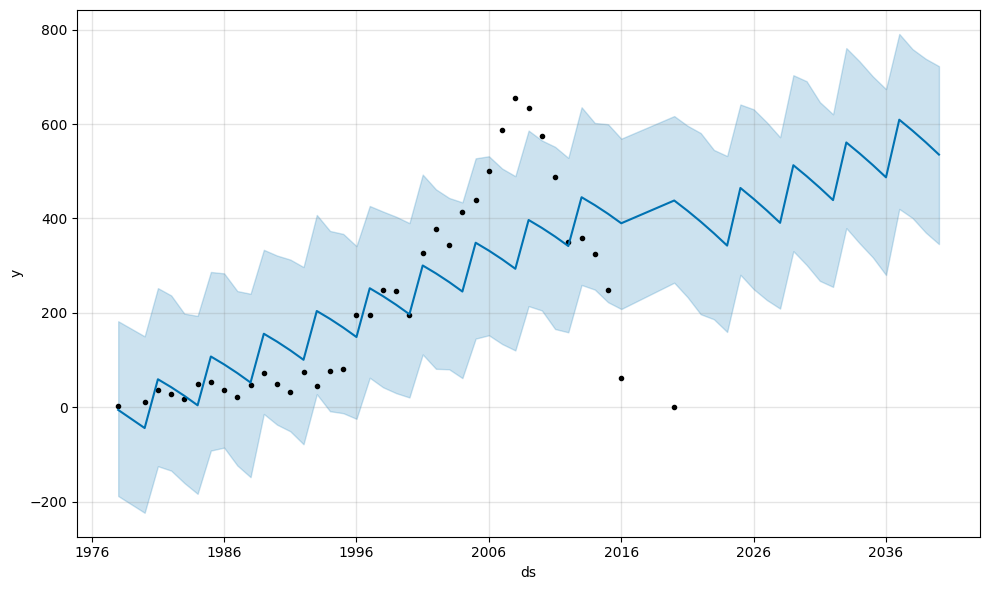

In [33]:
#予測グラフ
import matplotlib.pyplot as plt
fig = model.plot(forecast)
plt.show()